<a href="https://colab.research.google.com/github/xEzIxX/AI-Class/blob/master/week6/abalone_DL_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# abalone.csv
# DeepLearning
# 전복의 Rings 개수를 regression

In [2]:
import pandas as pd
import numpy as np;

file_path = '/content/drive/MyDrive/Colab Notebooks/abalone.csv'

df = pd.read_csv(file_path);
df.head()

,id,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [3]:
# 칼럼별 결측치 개수 확인
print(df.isnull().sum())

id                0
Sex               0
Length            0
Diameter          0
Height            0
Whole_weight      0
Shucked_weight    0
Viscera_weight    0
Shell_weight      0
Rings             0
dtype: int64


In [4]:
# 숫자값이 아닌 Sex는 전처리 필요하다
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Sex'] = le.fit_transform(df['Sex'])

df.head()

,id,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,0,2,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,1,2,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,2,0,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,3,2,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,4,1,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [5]:
# 정답(label) 데이터 설정
# Rings
y=df['Rings'];
print(y.value_counts());

Rings
9     689
10    634
8     568
11    487
7     391
12    267
6     259
13    203
14    126
5     115
15    103
16     67
17     58
4      57
18     42
19     32
20     26
3      15
21     14
23      9
22      6
24      2
27      2
1       1
29      1
26      1
2       1
25      1
Name: count, dtype: int64


In [6]:
Y = y.values

In [7]:
X=df.drop('Rings',axis=1)
X.head()

,id,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight
0,0,2,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150
1,1,2,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070
2,2,0,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210
3,3,2,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155
4,4,1,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055


In [8]:
# 딥러닝 입력을 위해 Numpy로 변환
X = X.values

In [9]:
from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [10]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=0)

# 모델 구성
model = models.Sequential([
    layers.Dense(64, activation="relu", input_shape=(X.shape[1],)), # input_shape 에 숫자로 칼럼 개수 지정 가능
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dense(1) # 회귀 (연속 값 예측)이므로 활성화 함수가 없다
])

# 컴파일, 학습
model.compile(
    optimizer="adam",
    loss="mae",
    metrics=["mae"]
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

y_pred = model.predict(X_test)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 5.3576 - mae: 5.3576 - val_loss: 2.4144 - val_mae: 2.4144
Epoch 2/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.1147 - mae: 2.1147 - val_loss: 1.7521 - val_mae: 1.7521
Epoch 3/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.9647 - mae: 1.9647 - val_loss: 1.7234 - val_mae: 1.7234
Epoch 4/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.8862 - mae: 1.8862 - val_loss: 1.6628 - val_mae: 1.6628
Epoch 5/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.8282 - mae: 1.8282 - val_loss: 1.6166 - val_mae: 1.6166
Epoch 6/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.7971 - mae: 1.7971 - val_loss: 1.6231 - val_mae: 1.6231
Epoch 7/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.7648 - mae: 1.7648 - val_loss: 1.6124 - val_mae: 1.6124
Epoch 8/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.7116 - mae: 1.7116 - val_loss: 1.5810 - val_mae: 1.5810
Epoch 9/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.6886 

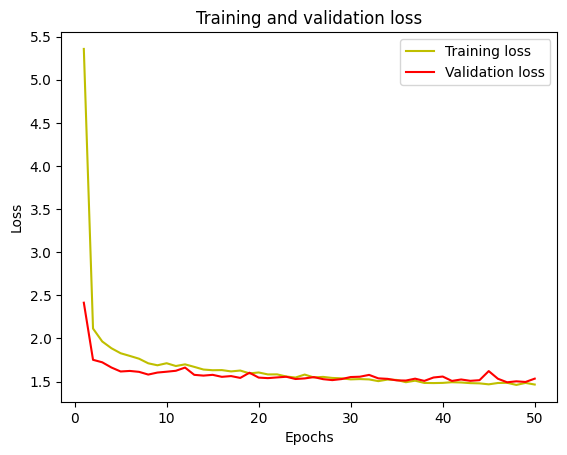

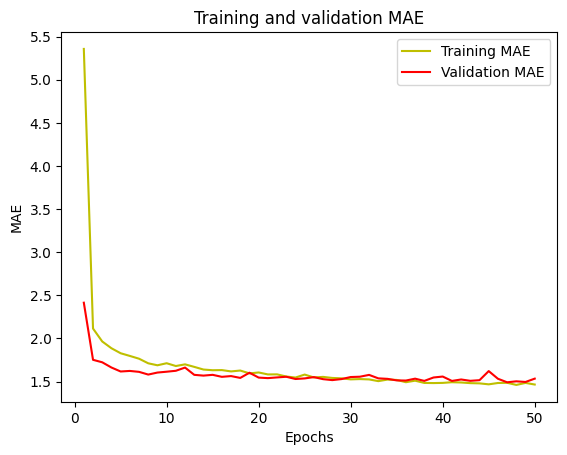

MAE : 1.4592372179031372
MSE : 4.470954895019531
RMSE: 2.1144632640506034


In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

loss = history.history['loss']
val_loss = history.history['val_loss']
mae = history.history['mae']
val_mae = history.history['val_mae']
epochs = range(1, len(loss) + 1)

# loss 그래프
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# MAE 그래프
plt.plot(epochs, mae, 'y', label='Training MAE')
plt.plot(epochs, val_mae, 'r', label='Validation MAE')
plt.title('Training and validation MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.show()

# 회귀 평가지표
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)